# LSTM + Transformer v5 — full sequence-track notebook

AWS privilege-escalation **sequence** model for the capstone fusion pipeline.

| Item | Value |
|---|---|
| Model | BiLSTM + 1-layer Transformer + tabular skip + **secrets head** |
| Data | `data/lstm/train_temporal_aug.csv` (`fe:` / `inv:` / `syn:`) |
| Train unit | one history per event (last 10 min, **T=32**, right-pad) |
| Loss | last-event only |
| Fusion | `P_seq = max(P_event)` in each 10-min / stride-2 window |
| Honest test | **`inv:bert-jan` held out** |
| Checkpoint | `artifacts/lstm_transformer/temporal_lstm_transformer.pt` |

**Headline to report (bert-jan, campaign labels, threshold 0.625):** precision **0.73**, recall **0.98**, F1 **0.83**, AUC-PR **0.95**.

Campaign labels mark `GetSecretValue` / `Decrypt` / `AssumeRole` / `CreateSecret` as attack if they follow a privilege-escalation write within 10 minutes. Original CSV labels under-count loot (178 in-campaign `Decrypt` are still 0).

Set `RUN_TRAIN = False` (default) to plot the **saved v5 run**. Set it `True` only if you want a full retrain (~4 min on CPU).


## 1. Setup


In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

import train_lstm_transformer as tlt

RUN_TRAIN = False  # True = retrain and overwrite artifacts

ROOT = Path(".").resolve()
OUT = tlt.OUT_DIR
PLOT_DIR = OUT / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 140,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titlesize": 13,
        "figure.facecolor": "white",
    }
)

device = tlt.torch.device("cuda" if tlt.torch.cuda.is_available() else "cpu")
tlt.set_seed()
print("device:", device)
print("csv:", tlt.CSV_PATH)
print("artifacts:", OUT)
print("RUN_TRAIN:", RUN_TRAIN)


device: cpu
csv: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\data\lstm\train_temporal_aug.csv
artifacts: C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer
RUN_TRAIN: False


## 2. Data overview

Three sources, usernames prefixed so windows never mix:

- `fe:` — fe-final synthetic CloudTrail templates  
- `inv:` — Invictus temporal (real-ish). Test attacker is **`inv:bert-jan`**  
- `syn:` — extra PE chains (train/val only)


campaign relabel: +294 events (orig_pos=1072 new_pos=1366)


,src,events,users,orig_pos,camp_pos
0,fe,9711,564,480,533
1,inv,2900,19,136,377
2,syn,1171,144,456,456


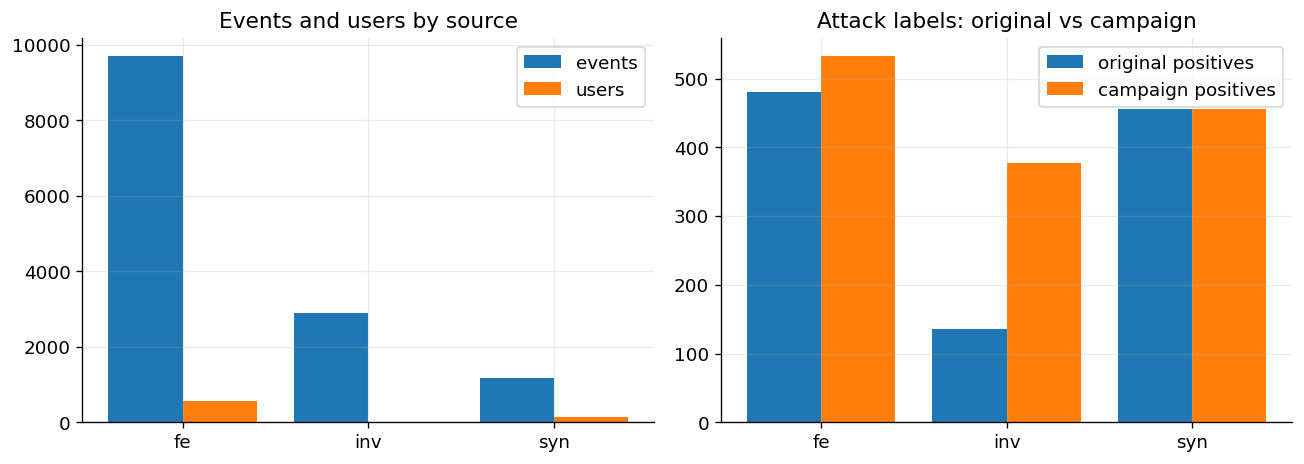

(13782, 45) vocab 281 campaign +labels 294


In [2]:
raw = pd.read_csv(tlt.CSV_PATH)
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
raw["src"] = raw["username"].str.split(":").str[0]

vocab = json.loads(tlt.VOCAB_PATH.read_text(encoding="utf-8"))
idx_to_name = {int(v): k for k, v in vocab.items()}
raw["event_name"] = raw["event_name_idx"].map(lambda i: idx_to_name.get(int(i), "<UNK>"))

pe_ids, sec_ids, extra_ids = tlt.vocab_id_sets(vocab)
ctx = tlt.attach_pe_context(raw, pe_ids)
ctx = tlt.relabel_campaign(ctx, sec_ids, extra_ids)

summary = (
    ctx.groupby("src")
    .agg(events=("log_id", "size"), users=("username", "nunique"), orig_pos=("label_orig", "sum"), camp_pos=("label", "sum"))
    .reset_index()
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(summary))
axes[0].bar(x - 0.2, summary["events"], 0.4, label="events")
axes[0].bar(x + 0.2, summary["users"], 0.4, label="users")
axes[0].set_xticks(x, summary["src"])
axes[0].set_title("Events and users by source")
axes[0].legend()

axes[1].bar(x - 0.2, summary["orig_pos"], 0.4, label="original positives")
axes[1].bar(x + 0.2, summary["camp_pos"], 0.4, label="campaign positives")
axes[1].set_xticks(x, summary["src"])
axes[1].set_title("Attack labels: original vs campaign")
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "01_data_overview.png")
plt.show()

print(ctx.shape, "vocab", len(vocab), "campaign +labels", int((ctx.label > ctx.label_orig).sum()))


## 3. Why campaign labels (bert-jan)

Original Invictus labels mark IAM writes + `GetSecretValue`, but **not** the in-campaign `Decrypt` / `AssumeRole` / `CreateSecret`. v4 caught IAM writes and missed all 60 `GetSecretValue` (score ~0.28) because T=32 dropped the PE write off a busy timeline.


,event_name,n,orig,camp
0,Decrypt,178,0,178
1,GetSecretValue,60,60,60
2,AssumeRole,23,0,23
3,GenerateDataKey,20,0,20
4,CreateSecret,20,0,20
5,CreateRole,13,13,13
6,AttachRolePolicy,6,6,6
7,PutRolePolicy,5,5,5
8,CreateUser,4,4,4
9,PutBucketPolicy,3,3,3


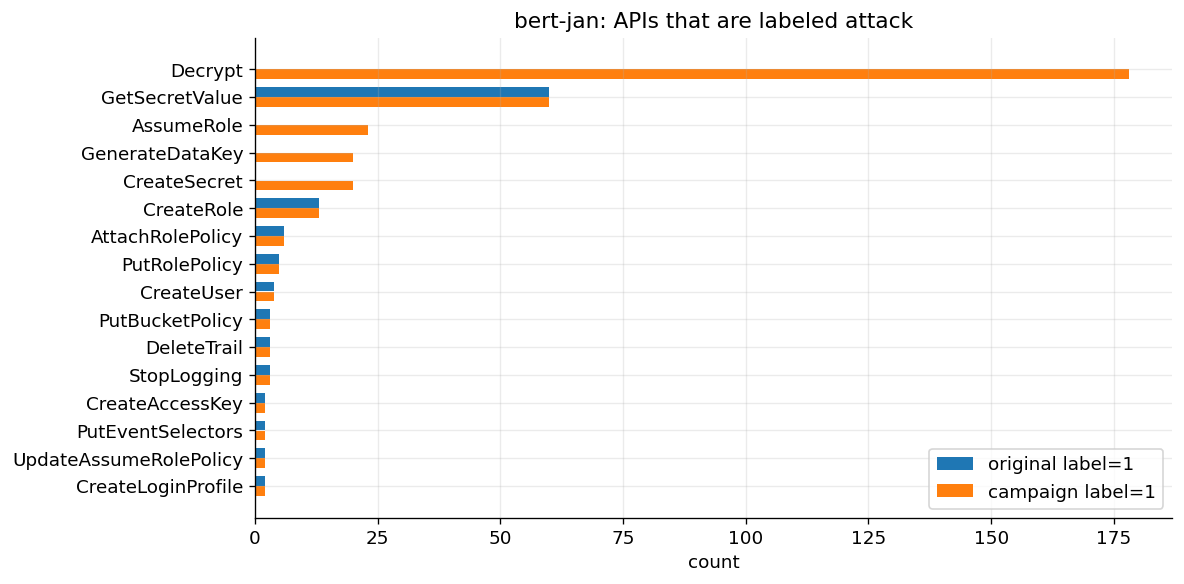

In [3]:
bj = ctx[ctx["username"] == tlt.BERT_JAN].copy()
api_tab = (
    bj.groupby("event_name")
    .agg(n=("log_id", "size"), orig=("label_orig", "sum"), camp=("label", "sum"))
    .sort_values("camp", ascending=False)
)
show = api_tab[(api_tab["orig"] > 0) | (api_tab["camp"] > 0)].head(16)
display(show.reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(show))
ax.barh(y - 0.18, show["orig"].to_numpy(), 0.35, label="original label=1")
ax.barh(y + 0.18, show["camp"].to_numpy(), 0.35, label="campaign label=1")
ax.set_yticks(y, show.index)
ax.invert_yaxis()
ax.set_xlabel("count")
ax.set_title("bert-jan: APIs that are labeled attack")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "02_bertjan_label_apis.png")
plt.show()


## 4. Model architecture

```
event_name_idx [B,32] ──► Embedding(281,16) ──► dropout
35 FE + Δt + pe_write_recent + log_secs_since_pe  [B,32,38]
        └─ concat [B,32,54] ─► packed BiLSTM(h=48) ─► LN ─► Transformer (1×, 4 heads)
                                                      │
                         z = h + σ(W log(1+L)) · tf   ┘
                         last step ─┬─ seq_head (112→1)
                                    ├─ tab_head  (38→1)     → IAM logit
                                    └─ secret_head if last API is secret → + secrets logit
P_event = σ(IAM + 1_secret · secrets)
P_seq   = max(P_event) in 10-min / stride-2 window
```

~120k parameters. Last-event token is **not** dropped to UNK. `pe_write_recent` is computed on the **full** user timeline so loot still sees a PE write after T=32 truncation.


## 5. Train or load the saved v5 run


In [4]:
ckpt_path = OUT / "temporal_lstm_transformer.pt"
if RUN_TRAIN:
    tlt.main()

assert ckpt_path.exists(), f"missing {ckpt_path} — run train_lstm_transformer.py or set RUN_TRAIN=True"
ckpt = tlt.torch.load(ckpt_path, map_location="cpu")
metrics = json.loads((OUT / "test_metrics.json").read_text(encoding="utf-8"))
hist = pd.read_csv(OUT / "training_history.csv")
events = pd.read_csv(OUT / "P_event.csv")
windows = pd.read_csv(OUT / "P_seq.csv")
events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True)

src = raw[["log_id", "event_name_idx", "event_name"]].drop_duplicates("log_id")
events = events.merge(src, on="log_id", how="left")
events["src"] = events["username"].str.split(":").str[0]
evt_thr = float(metrics["event_threshold"])
win_thr = float(metrics["window_threshold"])
print("event threshold", evt_thr, "window threshold", win_thr)
print("P_event", events.shape, "P_seq", windows.shape)
print("config", ckpt.get("config", {}).get("model"), "n_features", ckpt.get("config", {}).get("n_features"))
display(pd.DataFrame(
    {
        "split": ["train", "val", "test all", "test fe", "test bert-jan campaign"],
        "n": [metrics["train_event"]["n"], metrics["val_event"]["n"], metrics["test_event"]["n"],
              metrics["test_event_fe"]["n"], metrics["test_bertjan_campaign"]["n"]],
        "n_pos": [metrics["train_event"]["n_pos"], metrics["val_event"]["n_pos"], metrics["test_event"]["n_pos"],
                  metrics["test_event_fe"]["n_pos"], metrics["test_bertjan_campaign"]["n_pos"]],
        "precision": [metrics["train_event"]["precision"], metrics["val_event"]["precision"],
                      metrics["test_event"]["precision"], metrics["test_event_fe"]["precision"],
                      metrics["test_bertjan_campaign"]["precision"]],
        "recall": [metrics["train_event"]["recall"], metrics["val_event"]["recall"],
                   metrics["test_event"]["recall"], metrics["test_event_fe"]["recall"],
                   metrics["test_bertjan_campaign"]["recall"]],
        "f1": [metrics["train_event"]["f1"], metrics["val_event"]["f1"], metrics["test_event"]["f1"],
               metrics["test_event_fe"]["f1"], metrics["test_bertjan_campaign"]["f1"]],
        "auc_pr": [metrics["train_event"]["auc_pr"], metrics["val_event"]["auc_pr"], metrics["test_event"]["auc_pr"],
                   metrics["test_event_fe"]["auc_pr"], metrics["test_bertjan_campaign"]["auc_pr"]],
    }
).round(3))


event threshold 0.625 window threshold 0.85
P_event (13782, 9) P_seq (12195, 8)
config LSTMTransformerV5 n_features 38


,split,n,n_pos,precision,recall,f1,auc_pr
0,train,7339,467,1.000,0.998,0.999,1.000
1,val,1311,168,1.000,1.000,1.000,1.000
2,test all,4906,505,0.793,0.980,0.877,0.969
3,test fe,2264,157,0.994,0.981,0.987,0.999
4,test bert-jan campaign,2642,348,0.727,0.980,0.835,0.953


## 6. Training curves

Val F1 is the checkpoint score. Val Invictus AP saturates at 1.00 (stratus vs benjamin is easy) — do not treat that as generalization.


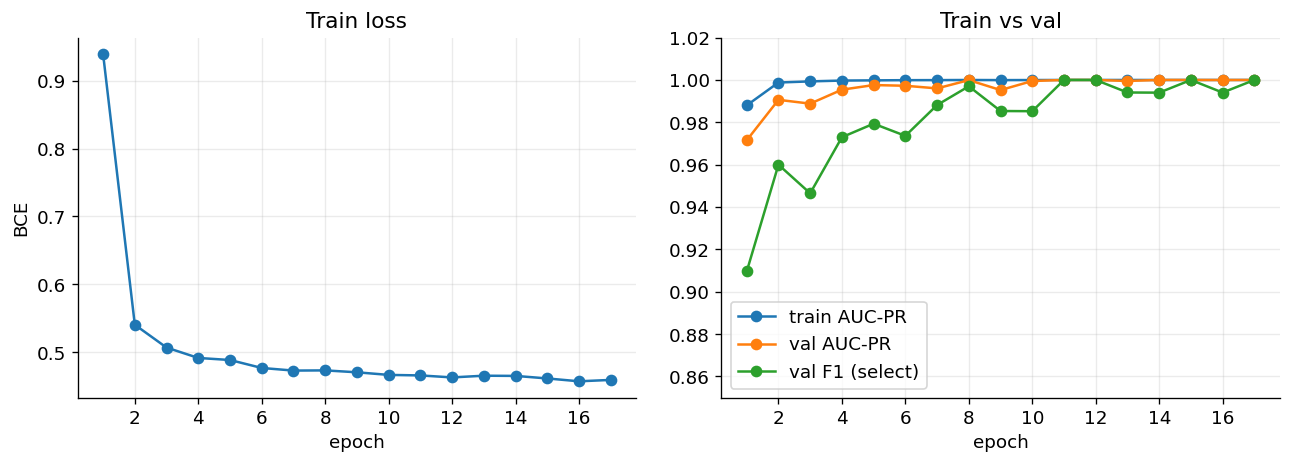

,epoch,train_loss,train_auc_pr,val_auc_pr,val_f1,select_score
0,1,0.9395,0.9880,0.9715,0.9096,0.9096
1,2,0.5403,0.9988,0.9906,0.9600,0.9600
2,3,0.5067,0.9993,0.9888,0.9465,0.9465
3,4,0.4914,0.9997,0.9954,0.9730,0.9730
4,5,0.4884,0.9998,0.9976,0.9794,0.9794
5,6,0.4766,0.9999,0.9973,0.9736,0.9736
6,7,0.4728,0.9999,0.9960,0.9882,0.9882
7,8,0.4731,1.0000,0.9999,0.9970,0.9970
8,9,0.4703,0.9999,0.9952,0.9853,0.9853
9,10,0.4664,1.0000,0.9995,0.9853,0.9853


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["epoch"], hist["train_loss"], marker="o")
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE")

axes[1].plot(hist["epoch"], hist["train_auc_pr"], marker="o", label="train AUC-PR")
axes[1].plot(hist["epoch"], hist["val_auc_pr"], marker="o", label="val AUC-PR")
axes[1].plot(hist["epoch"], hist["val_f1"], marker="o", label="val F1 (select)")
axes[1].set_title("Train vs val")
axes[1].set_xlabel("epoch")
axes[1].set_ylim(0.85, 1.02)
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "03_training_curves.png")
plt.show()
display(hist[["epoch", "train_loss", "train_auc_pr", "val_auc_pr", "val_f1", "select_score"]].round(4))


## 7. Headline metrics — v4 vs v5 (bert-jan)

v4 used original labels only (107 positives). v5 campaign labels are the intended detector target (348 positives). Both rows below are **the same held-out user**.


,setting,precision,recall,f1,auc_pr
0,v4 orig labels,0.380,0.430,0.400,0.522
1,v5 campaign labels,0.727,0.980,0.835,0.953
2,v5 orig labels (CSV),0.226,0.991,0.368,0.394


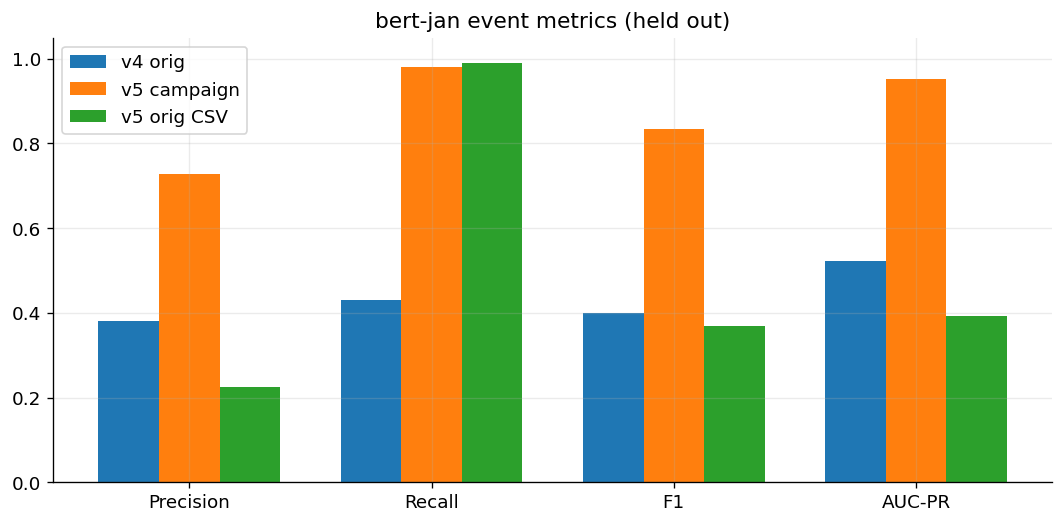

Use **v5 campaign** in the report. v5 on orig CSV looks like precision 0.23 because Decrypt/AssumeRole/CreateSecret are still labeled 0 in Invictus, not because ranking failed.

In [6]:
v4 = metrics["previous_v4"]
v5c = metrics["test_bertjan_campaign"]
v5o = metrics["test_bertjan_original"]

cmp = pd.DataFrame(
    {
        "setting": ["v4 orig labels", "v5 campaign labels", "v5 orig labels (CSV)"],
        "precision": [v4["test_inv_event_precision"], v5c["precision"], v5o["precision"]],
        "recall": [v4["test_inv_event_recall"], v5c["recall"], v5o["recall"]],
        "f1": [v4["test_inv_event_f1"], v5c["f1"], v5o["f1"]],
        "auc_pr": [v4["test_inv_event_auc_pr"], v5c["auc_pr"], v5o["auc_pr"]],
    }
)
display(cmp.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
labels = ["Precision", "Recall", "F1", "AUC-PR"]
x = np.arange(len(labels))
w = 0.25
ax.bar(x - w, [v4["test_inv_event_precision"], v4["test_inv_event_recall"], v4["test_inv_event_f1"], v4["test_inv_event_auc_pr"]], w, label="v4 orig")
ax.bar(x, [v5c["precision"], v5c["recall"], v5c["f1"], v5c["auc_pr"]], w, label="v5 campaign")
ax.bar(x + w, [v5o["precision"], v5o["recall"], v5o["f1"], v5o["auc_pr"]], w, label="v5 orig CSV")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.05)
ax.set_title("bert-jan event metrics (held out)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "04_v4_vs_v5_bertjan.png")
plt.show()

display(Markdown(
    "Use **v5 campaign** in the report. v5 on orig CSV looks like precision 0.23 because "
    "Decrypt/AssumeRole/CreateSecret are still labeled 0 in Invictus, not because ranking failed."
))


## 8. bert-jan score distributions, PR, ROC


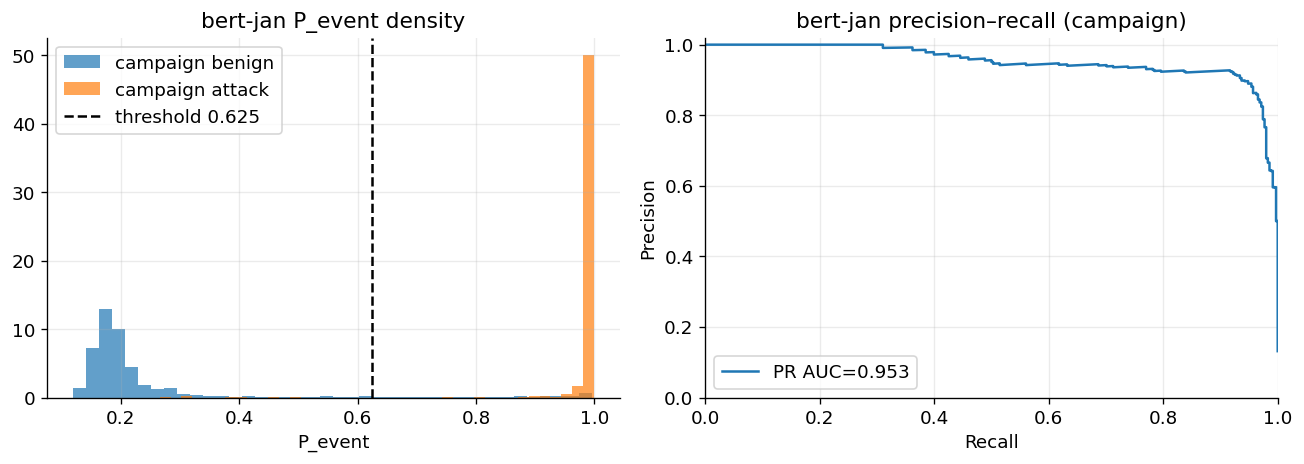

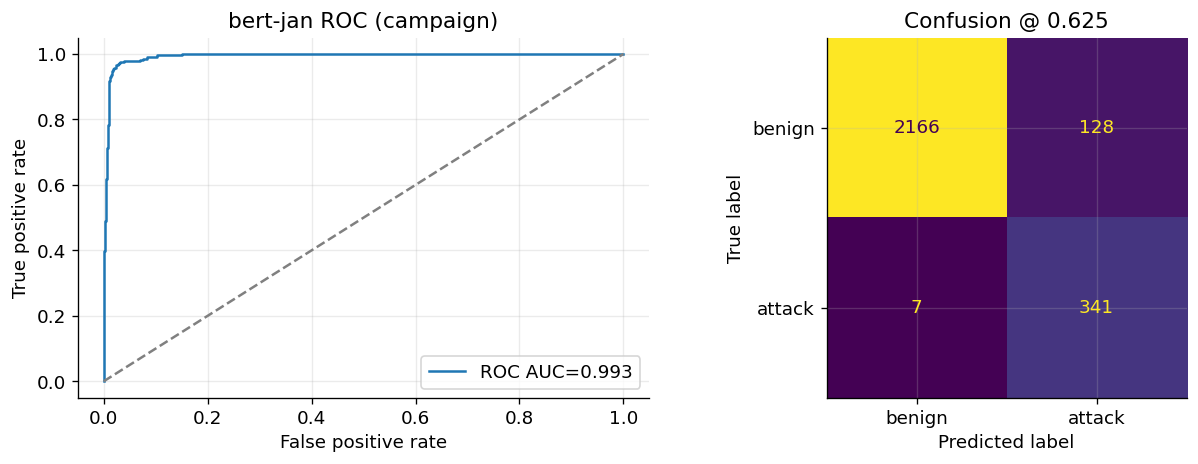

campaign {'accuracy': 0.9489023467070401, 'auc_pr': 0.9533961937335438, 'auc_roc': 0.9933346861878565, 'f1': 0.8347613219094248, 'precision': 0.7270788912579957, 'recall': 0.9798850574712644, 'threshold': 0.625, 'n': 2642, 'n_pos': 348}
original CSV {'accuracy': 0.8622255866767601, 'auc_pr': 0.3935277671701833, 'auc_roc': 0.9476967317369905, 'f1': 0.3680555555555556, 'precision': 0.2260127931769723, 'recall': 0.9906542056074766, 'threshold': 0.625, 'n': 2642, 'n_pos': 107}


In [7]:
bj_ev = events[events["username"] == tlt.BERT_JAN].copy()
y = bj_ev["label"].to_numpy()
p = bj_ev["P_event"].to_numpy()
pred = (p >= evt_thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(p[y == 0], bins=40, alpha=0.7, label="campaign benign", density=True)
axes[0].hist(p[y == 1], bins=40, alpha=0.7, label="campaign attack", density=True)
axes[0].axvline(evt_thr, color="black", ls="--", label=f"threshold {evt_thr:.3f}")
axes[0].set_title("bert-jan P_event density")
axes[0].set_xlabel("P_event")
axes[0].legend()

prec, rec, thr = precision_recall_curve(y, p)
fpr, tpr, _ = roc_curve(y, p)
axes[1].plot(rec, prec, label=f"PR AUC={average_precision_score(y, p):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("bert-jan precision–recall (campaign)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "05_bertjan_scores_pr.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f"ROC AUC={roc_auc_score(y, p):.3f}")
axes[0].plot([0, 1], [0, 1], ls="--", color="gray")
axes[0].set_title("bert-jan ROC (campaign)")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

cm = confusion_matrix(y, pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["benign", "attack"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion @ {evt_thr:.3f}")
fig.tight_layout()
fig.savefig(PLOT_DIR / "06_bertjan_roc_cm.png")
plt.show()

print("campaign", tlt.metrics_dict(y, p, evt_thr))
print("original CSV", tlt.metrics_dict(bj_ev["label_orig"].to_numpy(), p, evt_thr))


## 9. Precision / recall vs threshold (bert-jan campaign)


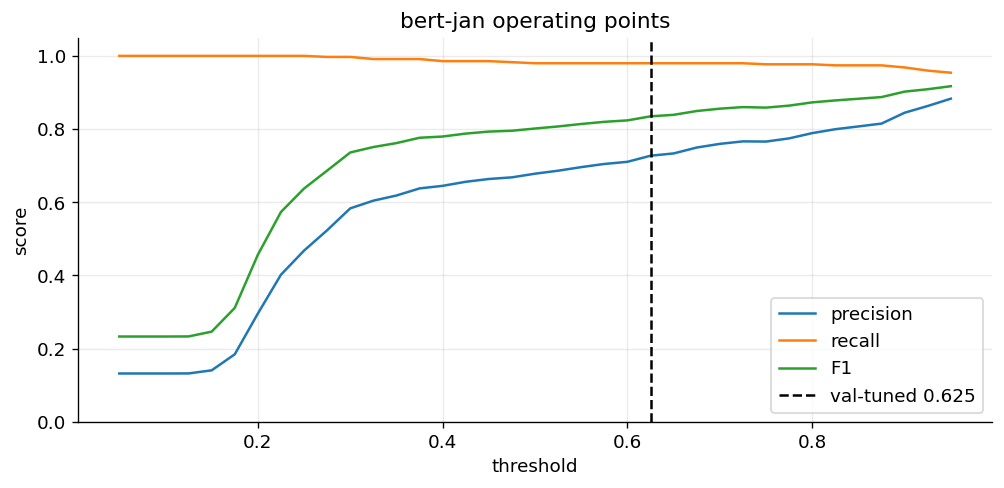

,t,precision,recall,f1
23,0.625,0.727,0.98,0.835
24,0.650,0.733,0.98,0.839
25,0.675,0.749,0.98,0.849


In [8]:
grid = np.linspace(0.05, 0.95, 37)
rows = []
for t in grid:
    pr = precision_score(y, p >= t, zero_division=0)
    rc = recall_score(y, p >= t, zero_division=0)
    rows.append({"t": t, "precision": pr, "recall": rc, "f1": f1_score(y, p >= t, zero_division=0)})
curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(curve["t"], curve["precision"], label="precision")
ax.plot(curve["t"], curve["recall"], label="recall")
ax.plot(curve["t"], curve["f1"], label="F1")
ax.axvline(evt_thr, color="black", ls="--", label=f"val-tuned {evt_thr:.3f}")
ax.set_xlabel("threshold")
ax.set_ylabel("score")
ax.set_title("bert-jan operating points")
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "07_threshold_sweep.png")
plt.show()
display(curve.iloc[(np.abs(curve["t"] - evt_thr)).argmin():].head(3).round(3))


## 10. Per-API errors on bert-jan (campaign labels)


TP 341 FP 128 FN 7


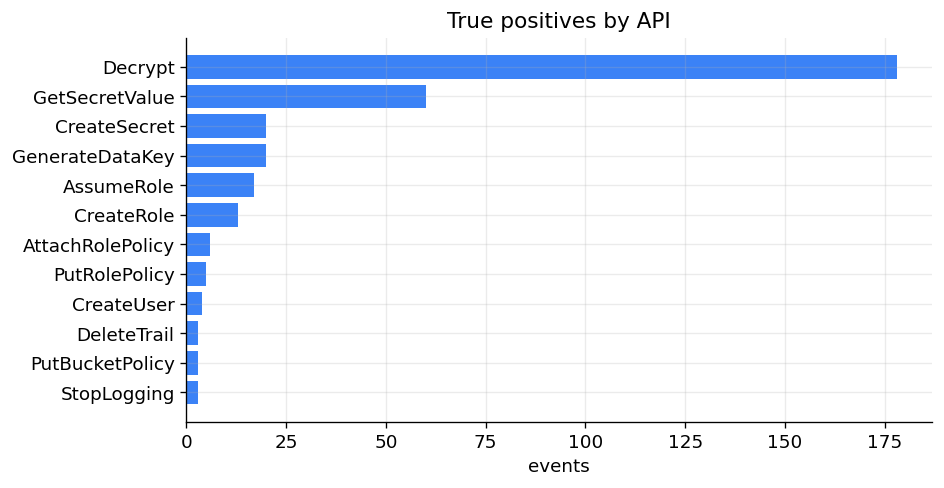

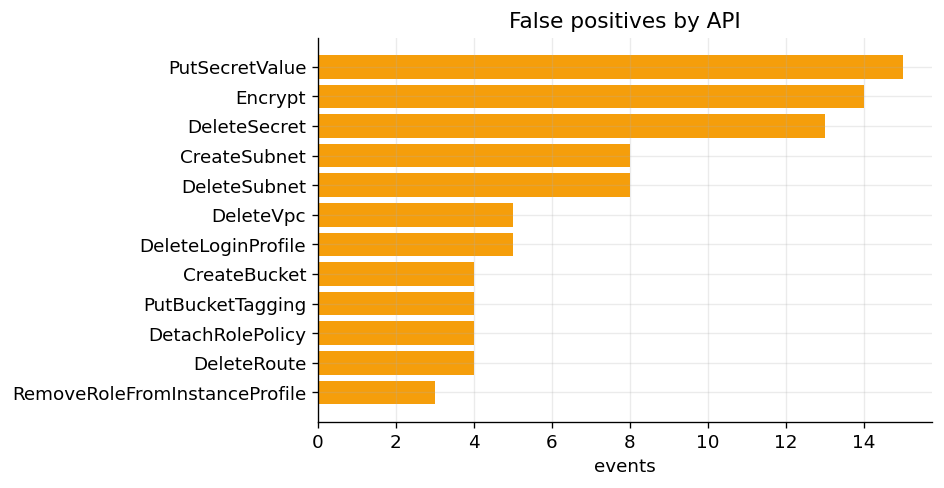

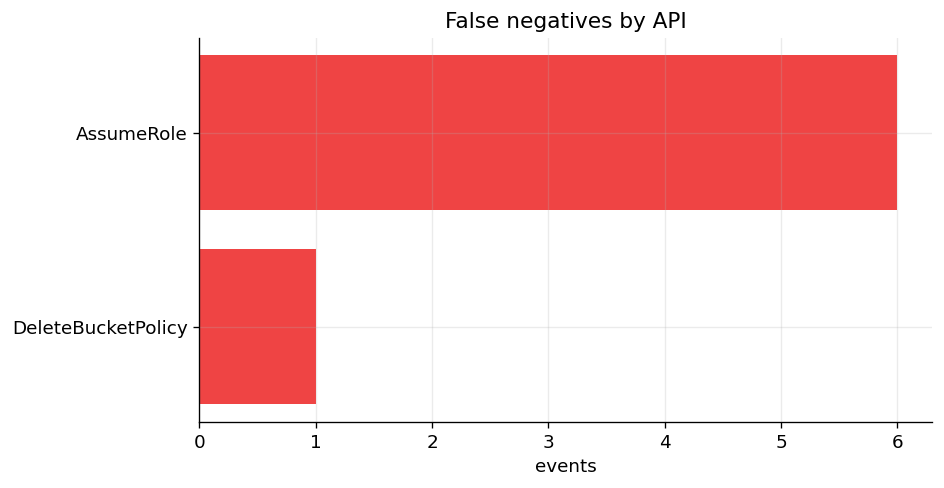

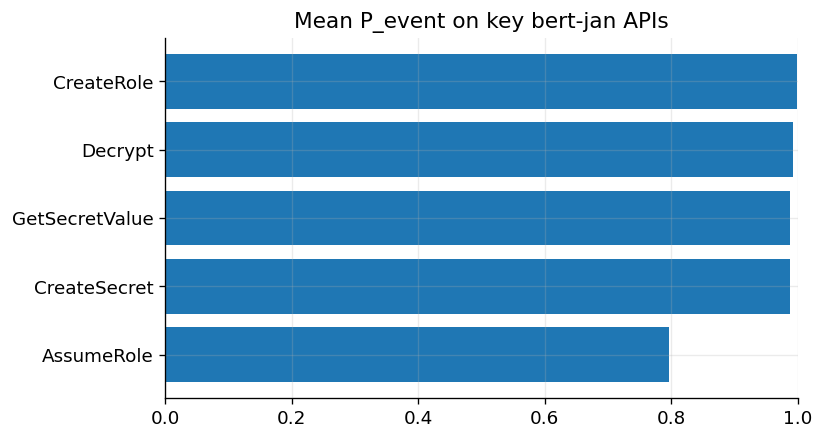

,mean_P_event
event_name,
AssumeRole,0.797
CreateSecret,0.987
GetSecretValue,0.988
Decrypt,0.993
CreateRole,0.998


In [9]:
bj_ev = bj_ev.copy()
bj_ev["pred"] = (bj_ev["P_event"] >= evt_thr).astype(int)
fn = bj_ev[(bj_ev["label"] == 1) & (bj_ev["pred"] == 0)]
fp = bj_ev[(bj_ev["label"] == 0) & (bj_ev["pred"] == 1)]
tp = bj_ev[(bj_ev["label"] == 1) & (bj_ev["pred"] == 1)]

def top_bar(series, title, fname, color):
    c = Counter(series.fillna("?"))
    names, vals = zip(*c.most_common(12)) if c else ([], [])
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.barh(list(names)[::-1], list(vals)[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("events")
    fig.tight_layout()
    fig.savefig(PLOT_DIR / fname)
    plt.show()

print("TP", len(tp), "FP", len(fp), "FN", len(fn))
top_bar(tp["event_name"], "True positives by API", "08_tp_apis.png", "#3b82f6")
top_bar(fp["event_name"], "False positives by API", "09_fp_apis.png", "#f59e0b")
top_bar(fn["event_name"], "False negatives by API", "10_fn_apis.png", "#ef4444")

loot = bj_ev[bj_ev["event_name"].isin(["GetSecretValue", "Decrypt", "AssumeRole", "CreateSecret", "CreateRole"])]
g = loot.groupby("event_name")["P_event"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(g.index, g.values)
ax.set_xlim(0, 1)
ax.set_title("Mean P_event on key bert-jan APIs")
fig.tight_layout()
fig.savefig(PLOT_DIR / "11_key_api_scores.png")
plt.show()
display(g.round(3).to_frame("mean_P_event"))


## 11. Event scores vs fusion windows

Windows look better because `max()` over a burst marks every overlapping 10-min window if **any** event fires. Report **event** bert-jan numbers, not window accuracy.


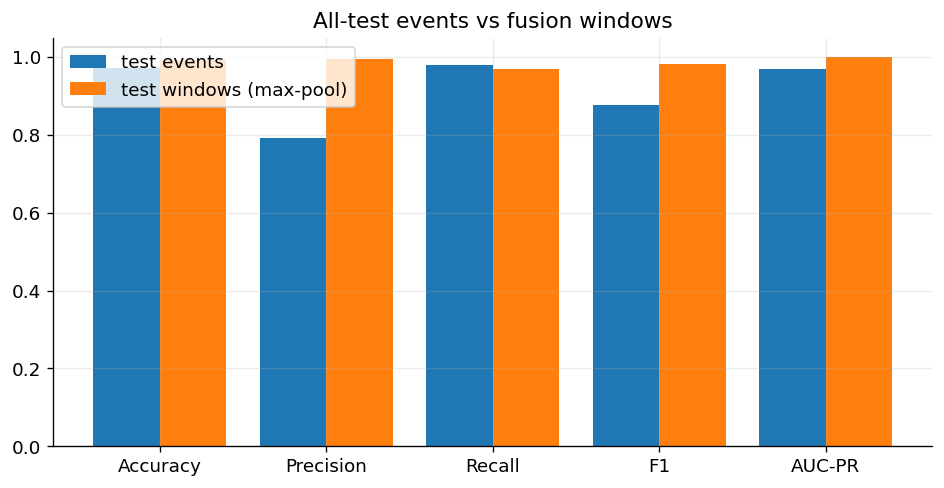

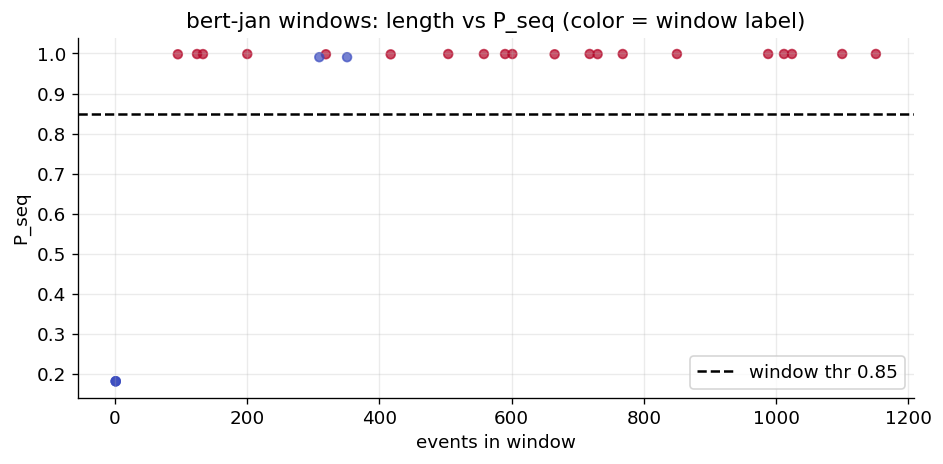

test windows {'accuracy': 0.992, 'auc_pr': 0.999, 'auc_roc': 1.0, 'f1': 0.982, 'precision': 0.995, 'recall': 0.969, 'threshold': 0.85, 'n': 1853, 'n_pos': 385}
bert-jan windows {'accuracy': 0.92, 'auc_pr': 1.0, 'auc_roc': 1.0, 'f1': 0.9523809523809523, 'precision': 0.9090909090909091, 'recall': 1.0, 'threshold': 0.85, 'n': 25, 'n_pos': 20}


In [10]:
ev_row = metrics["test_event"]
win_row = metrics["test"]
fig, ax = plt.subplots(figsize=(8, 4.2))
labs = ["Accuracy", "Precision", "Recall", "F1", "AUC-PR"]
x = np.arange(len(labs))
ax.bar(x - 0.2, [ev_row["accuracy"], ev_row["precision"], ev_row["recall"], ev_row["f1"], ev_row["auc_pr"]], 0.4, label="test events")
ax.bar(x + 0.2, [win_row["accuracy"], win_row["precision"], win_row["recall"], win_row["f1"], win_row["auc_pr"]], 0.4, label="test windows (max-pool)")
ax.set_xticks(x, labs)
ax.set_ylim(0, 1.05)
ax.set_title("All-test events vs fusion windows")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "12_event_vs_window.png")
plt.show()

bj_win = windows[windows["username"] == tlt.BERT_JAN]
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(bj_win["raw_len"], bj_win["P_seq"], c=bj_win["window_label"], cmap="coolwarm", alpha=0.7, s=28)
ax.axhline(win_thr, color="black", ls="--", label=f"window thr {win_thr:.2f}")
ax.set_xlabel("events in window")
ax.set_ylabel("P_seq")
ax.set_title("bert-jan windows: length vs P_seq (color = window label)")
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / "13_window_scatter.png")
plt.show()
print("test windows", {k: round(v, 3) if isinstance(v, float) else v for k, v in win_row.items()})
print("bert-jan windows", tlt.subset_metrics(bj_win, win_thr, None))


## 12. Split protocol (no bert-jan leakage)

| Bucket | Train | Val | Test |
|---|---|---|---|
| Invictus attackers | (none as attacker; other `inv:` service users may be train neg) | `stratus-red-team-ec2-get-password-data-role` + `benjamin` | **`bert-jan`** |
| `syn:` PE chains | ~85% users | ~15% | none |
| `fe:` templates | 70% of remaining | from train remainder | 30% users |

`syn:` never goes to test. Features `pe_write_recent` / `log_secs_since_pe` use **past** timestamps only.


## 13. Figure index and report line


In [11]:
print("Wrote figures to", PLOT_DIR)
for p in sorted(PLOT_DIR.glob("*.png")):
    print(" ", p.name)
line = (
    f"**Report line:** LSTM-Transformer v5, held-out inv:bert-jan, campaign labels, "
    f"threshold {evt_thr:.3f}: precision {v5c['precision']:.2f} / recall {v5c['recall']:.2f} "
    f"/ F1 {v5c['f1']:.2f} / AUC-PR {v5c['auc_pr']:.2f}. "
    "Fusion still emits P_seq.csv for the GNN window grid."
)
display(Markdown(line))


Wrote figures to C:\Users\nanda\OneDrive\Desktop\Capstone-2027\artifacts\lstm_transformer\plots
  01_data_overview.png
  02_bertjan_label_apis.png
  03_training_curves.png
  04_v4_vs_v5_bertjan.png
  05_bertjan_scores_pr.png
  06_bertjan_roc_cm.png
  07_threshold_sweep.png
  08_tp_apis.png
  09_fp_apis.png
  10_fn_apis.png
  11_key_api_scores.png
  12_event_vs_window.png
  13_window_scatter.png


**Report line:** LSTM-Transformer v5, held-out inv:bert-jan, campaign labels, threshold 0.625: precision 0.73 / recall 0.98 / F1 0.83 / AUC-PR 0.95. Fusion still emits P_seq.csv for the GNN window grid.